# 01 - EDA Metrics

Mục tiêu notebook này là đọc toàn bộ metrics, kiểm tra chất lượng dữ liệu, hiểu schema từng service, và vẽ các metric chính trước khi chạy anomaly detector.

Trong bài này, chúng ta phân tích **metrics trước** vì metrics là tín hiệu định lượng theo thời gian. Metrics giúp trả lời hai câu hỏi đầu:

- **WHEN**: anomaly bắt đầu từ khi nào?
- **WHERE**: service nào có dấu hiệu bất thường trước?

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "g2-data" / "g2").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing g2-data/g2")

ROOT = find_project_root()
DATA = ROOT / "g2-data" / "g2"
METRICS = DATA / "metrics"
PLOTS = ROOT / "lab" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

def format_time_axis(ax, interval=3):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.tick_params(axis="x", labelrotation=0, labelsize=8, labelbottom=True)

def load_all_metrics():
    loaded = {}
    for path in sorted(METRICS.glob("*.csv")):
        df = pd.read_csv(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        loaded[path.stem] = df
    return loaded

def ensure_services():
    if "services" not in globals() or not services:
        return load_all_metrics()
    return services

services = load_all_metrics()

sorted(services)

['api-gateway',
 'cart-service',
 'order-service',
 'payment-service',
 'product-service']

## 1.1 Kiểm tra schema và số dòng

In [3]:
services = ensure_services()

overview = []
for service, df in services.items():
    overview.append({
        "service": service,
        "rows": len(df),
        "columns": ", ".join(df.columns),
        "start": df["timestamp"].min(),
        "end": df["timestamp"].max(),
        "nulls": int(df.isna().sum().sum()),
        "unique_timestamps": df["timestamp"].nunique(),
    })
pd.DataFrame(overview)

,service,rows,columns,start,end,nulls,unique_timestamps
0,api-gateway,2820,"timestamp, http_requests_per_sec, http_p99_lat...",2026-06-01 00:00:00+00:00,2026-06-01 23:59:30+00:00,0,2820
1,cart-service,2820,"timestamp, memory_usage_bytes, memory_limit_by...",2026-06-01 00:00:00+00:00,2026-06-01 23:59:30+00:00,0,2820
2,order-service,2820,"timestamp, http_requests_per_sec, http_p99_lat...",2026-06-01 00:00:00+00:00,2026-06-01 23:59:30+00:00,0,2820
3,payment-service,2820,"timestamp, http_requests_per_sec, http_p99_lat...",2026-06-01 00:00:00+00:00,2026-06-01 23:59:30+00:00,0,2820
4,product-service,2820,"timestamp, http_requests_per_sec, http_p99_lat...",2026-06-01 00:00:00+00:00,2026-06-01 23:59:30+00:00,0,2820


## 1.2 Kiểm tra gap timestamp

In [4]:
services = ensure_services()

gaps = []
for service, df in services.items():
    diffs = df["timestamp"].diff()
    bad = df[diffs > pd.Timedelta(seconds=30)]
    for idx, row in bad.iterrows():
        prev = df.loc[idx - 1, "timestamp"]
        missing = int((row["timestamp"] - prev).total_seconds() / 30) - 1
        gaps.append({
            "service": service,
            "gap_start_after": prev,
            "next_timestamp": row["timestamp"],
            "missing_30s_points": missing,
        })
pd.DataFrame(gaps)

,service,gap_start_after,next_timestamp,missing_30s_points
0,api-gateway,2026-06-01 11:29:30+00:00,2026-06-01 12:00:00+00:00,60
1,cart-service,2026-06-01 11:29:30+00:00,2026-06-01 12:00:00+00:00,60
2,order-service,2026-06-01 11:29:30+00:00,2026-06-01 12:00:00+00:00,60
3,payment-service,2026-06-01 11:29:30+00:00,2026-06-01 12:00:00+00:00,60
4,product-service,2026-06-01 11:29:30+00:00,2026-06-01 12:00:00+00:00,60


Kết quả cho thấy tất cả file metrics đều thiếu 60 điểm từ `11:30Z` đến `11:59:30Z`. Gap này cần ghi vào report, nhưng không che mất failure window chính vì incident rõ nhất xảy ra từ sau `14:00Z`.

## 1.3 Thống kê min/median/mean/max từng metric

In [5]:
services = ensure_services()

rows = []
for service, df in services.items():
    for col in df.columns:
        if col == "timestamp":
            continue
        rows.append({
            "service": service,
            "metric": col,
            "min": df[col].min(),
            "median": df[col].median(),
            "mean": df[col].mean(),
            "max": df[col].max(),
            "max_at": df.loc[df[col].idxmax(), "timestamp"],
        })
metric_summary = pd.DataFrame(rows)
metric_summary

,service,metric,min,median,mean,max,max_at
0,api-gateway,http_requests_per_sec,2.384000e+01,7.352000e+01,7.553100e+01,1.266000e+02,2026-06-01 19:34:00+00:00
1,api-gateway,http_p99_latency_ms,1.000000e+01,2.260000e+01,2.782138e+01,1.255000e+02,2026-06-01 23:15:30+00:00
2,api-gateway,http_5xx_rate,0.000000e+00,1.800000e-01,1.199128e+00,1.164000e+01,2026-06-01 23:36:00+00:00
3,api-gateway,cart_upstream_error_rate,0.000000e+00,4.700000e-01,1.829954e+00,2.016000e+01,2026-06-01 23:43:00+00:00
4,api-gateway,product_upstream_error_rate,0.000000e+00,1.600000e-01,4.194823e-01,9.840000e+00,2026-06-01 03:40:00+00:00
5,api-gateway,active_connections,2.840000e+02,3.830000e+02,3.885433e+02,5.270000e+02,2026-06-01 20:05:00+00:00
6,cart-service,memory_usage_bytes,2.936013e+08,4.689482e+08,5.622971e+08,1.738625e+09,2026-06-01 19:59:00+00:00
7,cart-service,memory_limit_bytes,2.147484e+09,2.147484e+09,2.147484e+09,2.147484e+09,2026-06-01 00:00:00+00:00
8,cart-service,cpu_usage_percent,2.000000e+00,2.840000e+01,3.066650e+01,6.941000e+01,2026-06-01 20:46:00+00:00
9,cart-service,http_requests_per_sec,1.519000e+01,4.566500e+01,4.715765e+01,8.323000e+01,2026-06-01 19:54:30+00:00


## 1.4 Request rate theo service

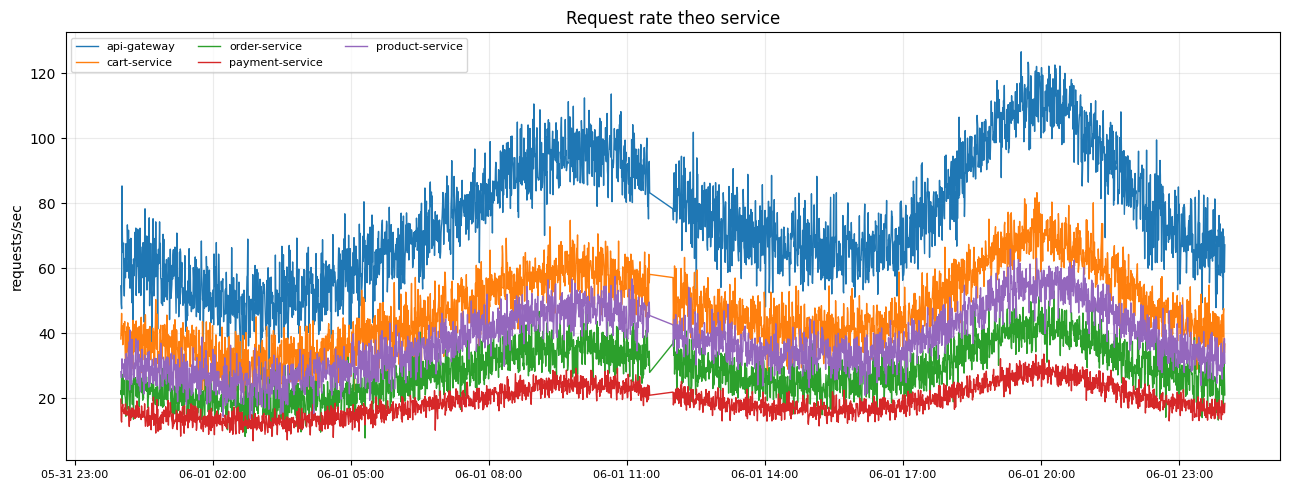

In [6]:
services = ensure_services()

fig, ax = plt.subplots(figsize=(13, 5))
for name, df in services.items():
    if "http_requests_per_sec" in df:
        ax.plot(df["timestamp"], df["http_requests_per_sec"], label=name, linewidth=1)
ax.set_title("Request rate theo service")
ax.set_ylabel("requests/sec")
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, fontsize=8)
format_time_axis(ax)
fig.tight_layout()
fig.savefig(PLOTS / "01_eda_request_rates.png", dpi=160)
plt.show()

**Request rate theo service**

![Request rate theo service](../plots/01_eda_request_rates.png)

## 1.5 Cart-service core metrics

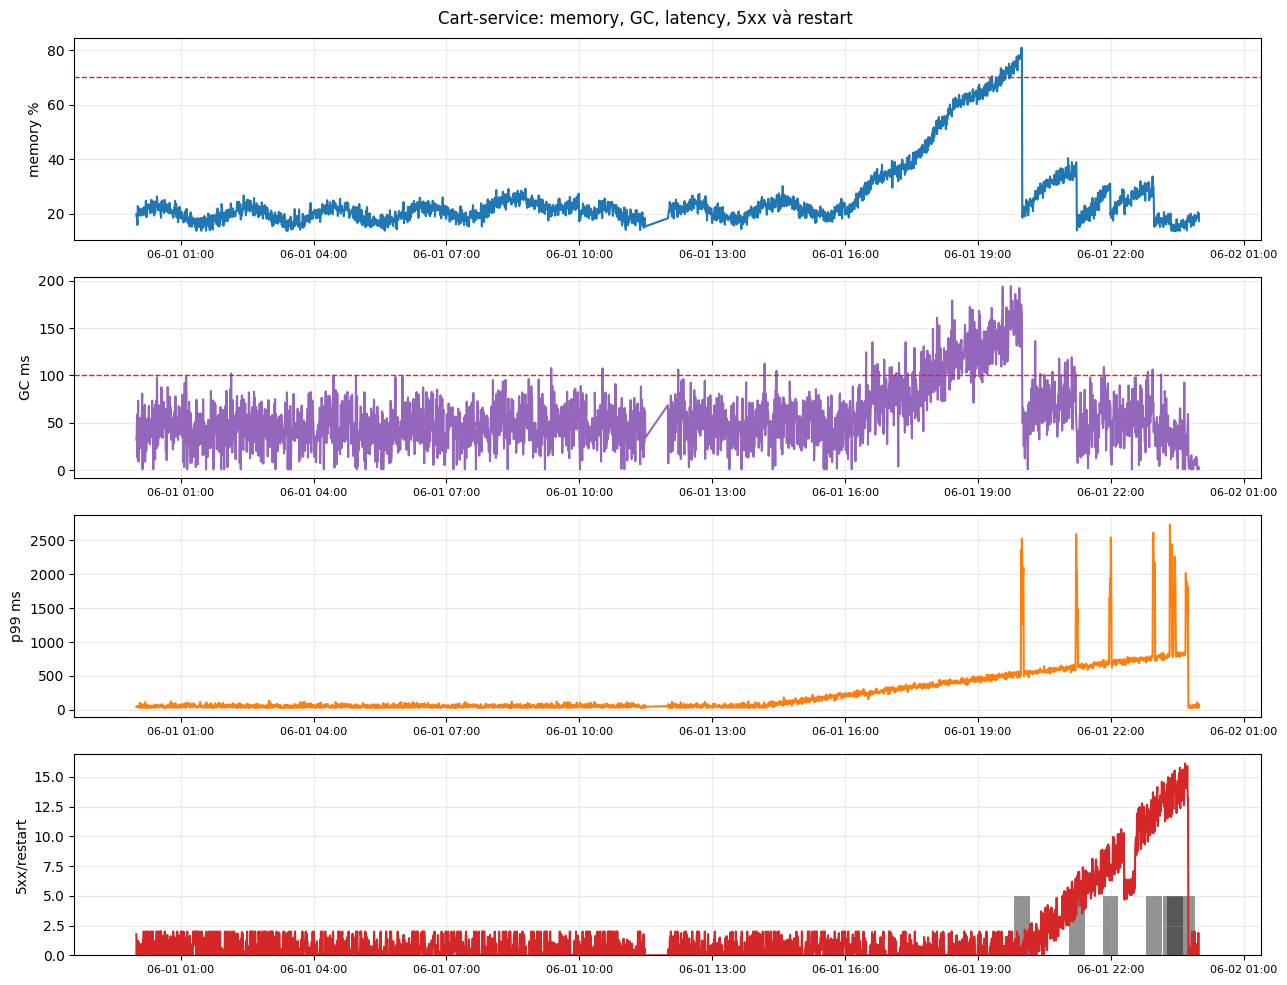

In [7]:
services = ensure_services()

cart = services["cart-service"].copy()
cart["memory_pct"] = 100 * cart["memory_usage_bytes"] / cart["memory_limit_bytes"]
cart["restart_delta"] = cart["container_restart_count"].diff().fillna(0)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(cart["timestamp"], cart["memory_pct"], color="#1f77b4")
axes[0].axhline(70, color="#d62728", linestyle="--", linewidth=1)
axes[0].set_ylabel("memory %")
axes[1].plot(cart["timestamp"], cart["jvm_gc_pause_ms_avg"], color="#9467bd")
axes[1].axhline(100, color="#d62728", linestyle="--", linewidth=1)
axes[1].set_ylabel("GC ms")
axes[2].plot(cart["timestamp"], cart["http_p99_latency_ms"], color="#ff7f0e")
axes[2].set_ylabel("p99 ms")
axes[3].plot(cart["timestamp"], cart["http_5xx_rate"], color="#d62728")
axes[3].bar(cart["timestamp"], cart["restart_delta"] * 5, width=0.015, color="#111111", alpha=0.45)
axes[3].set_ylabel("5xx/restart")
for ax in axes:
    ax.grid(True, alpha=0.25)
    format_time_axis(ax)
fig.suptitle("Cart-service: memory, GC, latency, 5xx và restart")
fig.tight_layout()
fig.savefig(PLOTS / "01_eda_cart_core_metrics.png", dpi=160)
plt.show()

**Cart-service core metrics**

![Cart-service core metrics](../plots/01_eda_cart_core_metrics.png)

Nhìn EDA ban đầu, `cart-service` có chuỗi rất đáng nghi: latency tăng trước, GC tăng, memory tăng, sau đó mới đến restart và 5xx. Đây là dấu hiệu của resource pressure, không chỉ là lỗi HTTP đơn thuần.

## 1.6 Downstream failures

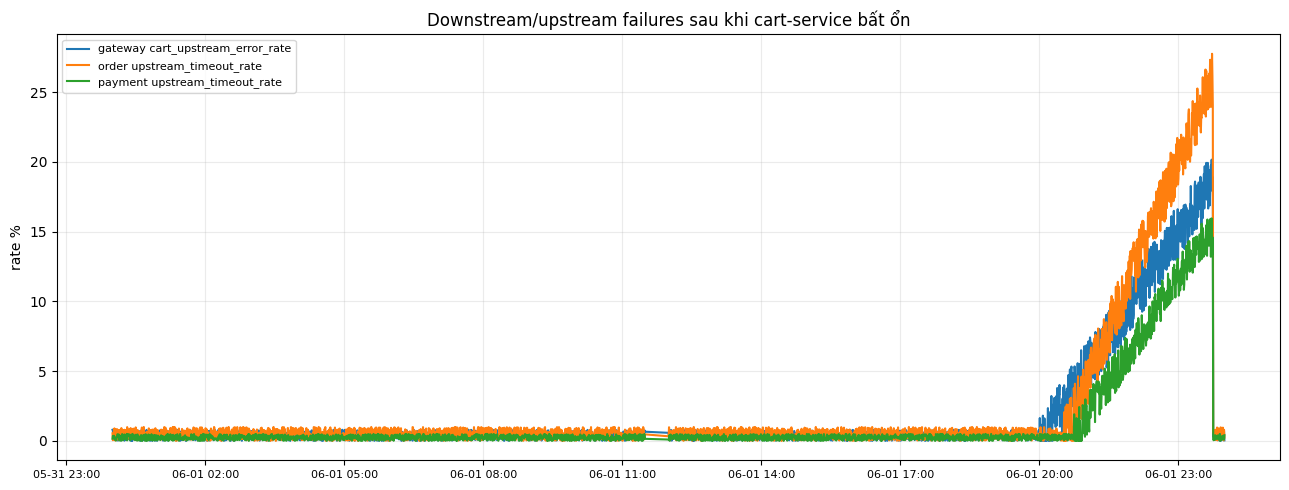

In [8]:
services = ensure_services()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(services["api-gateway"]["timestamp"], services["api-gateway"]["cart_upstream_error_rate"], label="gateway cart_upstream_error_rate")
ax.plot(services["order-service"]["timestamp"], services["order-service"]["upstream_timeout_rate"], label="order upstream_timeout_rate")
ax.plot(services["payment-service"]["timestamp"], services["payment-service"]["upstream_timeout_rate"], label="payment upstream_timeout_rate")
ax.set_title("Downstream/upstream failures sau khi cart-service bất ổn")
ax.set_ylabel("rate %")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
format_time_axis(ax)
fig.tight_layout()
fig.savefig(PLOTS / "01_eda_downstream_failures.png", dpi=160)
plt.show()

**Downstream failures**

![Downstream failures](../plots/01_eda_downstream_failures.png)

## 1.7 Product-service early suspicious signal

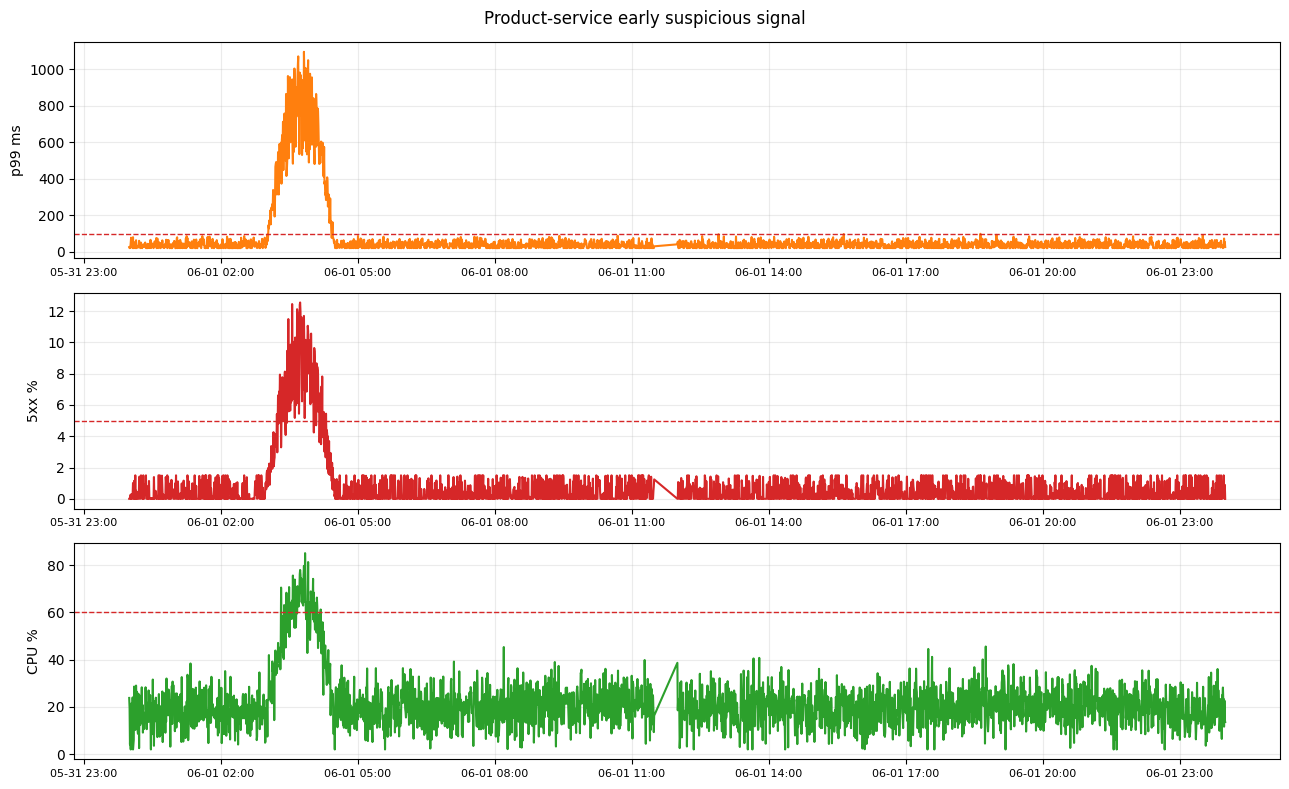

In [9]:
services = ensure_services()

product = services["product-service"]
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(product["timestamp"], product["http_p99_latency_ms"], color="#ff7f0e")
axes[0].axhline(100, color="#d62728", linestyle="--", linewidth=1)
axes[0].set_ylabel("p99 ms")
axes[1].plot(product["timestamp"], product["http_5xx_rate"], color="#d62728")
axes[1].axhline(5, color="#d62728", linestyle="--", linewidth=1)
axes[1].set_ylabel("5xx %")
axes[2].plot(product["timestamp"], product["cpu_usage_percent"], color="#2ca02c")
axes[2].axhline(60, color="#d62728", linestyle="--", linewidth=1)
axes[2].set_ylabel("CPU %")
for ax in axes:
    ax.grid(True, alpha=0.25)
    format_time_axis(ax)
fig.suptitle("Product-service early suspicious signal")
fig.tight_layout()
fig.savefig(PLOTS / "01_eda_product_service_anomaly.png", dpi=160)
plt.show()

**Product-service early suspicious signal**

![Product-service early suspicious signal](../plots/01_eda_product_service_anomaly.png)

`product-service` có anomaly sớm khoảng `03:03Z`. Tuy nhiên ở bước EDA ta chỉ gọi đây là **early suspicious signal / possible trigger**, chưa gọi là root cause vì chưa có log/trace chứng minh quan hệ trực tiếp với cart.